--- STEP 1: DATASET ---
    Study_Hrs  Project_Hrs  Final_Grade
0           2            1           45
1           4            2           52
2           5            3           58
3           7            5           65
4           8            4           70
5          10            6           78
6          12            8           82
7          14            7           88
8          15            9           92
9          18           10           98
10          3            1           47
11          4            3           54
12          5            2           57
13          6            4           62
14          6            2           60
15          7            3           63
16          8            5           71
17          9            4           69
18          9            6           74
19         10            4           75
20         11            5           77
21         11            7           80
22         12            5           79
23         13   

c:\Users\DAKSH\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


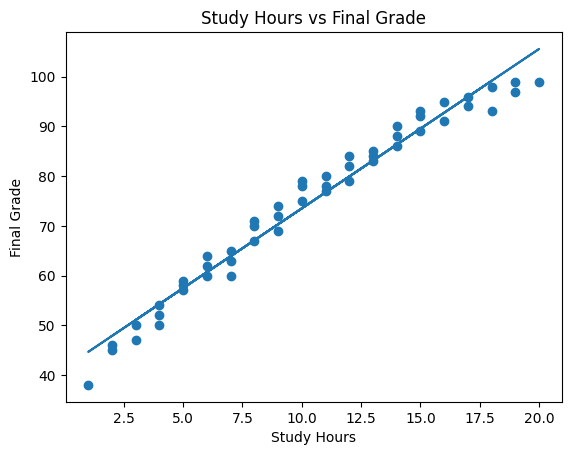

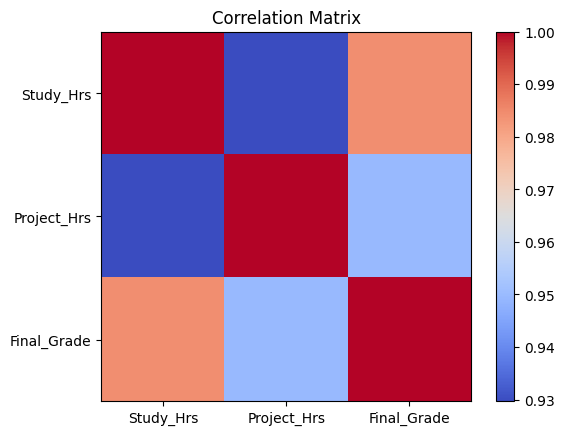

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- STEP 1: DATA PREPARATION ---

df = pd.read_csv("data.csv")

print("--- STEP 1: DATASET ---")
print(df)

# --- STEP 2: CORRELATION ---
corr_matrix = df.corr()

print("\n--- STEP 2: CORRELATION COEFFICIENTS ---")
print(corr_matrix['Final_Grade'].round(4))

# --- STEP 3: REGRESSION MODEL ---
X = df[['Study_Hrs']]
Y = df['Final_Grade']

model = LinearRegression()
model.fit(X, Y)

m = model.coef_[0]
c = model.intercept_
r_sq = model.score(X, Y)

print("\n--- STEP 3: REGRESSION PARAMETERS ---")
print("Slope (m):", m)
print("Intercept (c):", c)
print("R-Squared:", round(r_sq, 4))

# --- STEP 4: PREDICTION (FIXED) ---
new_input = np.array([[11]])   # 
prediction = model.predict(new_input)

print("\n--- STEP 4: PREDICTION ---")
print("Predicted Grade for 11 Study Hours:", round(prediction[0], 2))

# --- STEP 5: VISUALIZATION (MATPLOTLIB ONLY) ---

# 1. Scatter Plot
plt.figure()
plt.scatter(df['Study_Hrs'], df['Final_Grade'])

# Regression Line
y_pred_line = model.predict(X)
plt.plot(df['Study_Hrs'], y_pred_line)

plt.title("Study Hours vs Final Grade")
plt.xlabel("Study Hours")
plt.ylabel("Final Grade")
plt.show()

# 2. Correlation Heatmap (manual)
plt.figure()
plt.imshow(corr_matrix, cmap='coolwarm')

plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.show()